In [1]:
import astropy
import astroquery.simbad
import numpy as np
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
from astropy.coordinates import SkyCoord
import pyarrow
import pyvo
from astroquery.simbad import Simbad
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
from collections import Counter
import timeit
import matplotlib.pyplot as plt
import pandas
import os
import numpy.ma as ma

In [2]:
%load_ext autoreload
%autoreload 1
%aimport crossmatching
from crossmatching import Crossmatcher


In [3]:
cm = Crossmatcher()
cm.load_catalog(from_file="pscomppars.txt")
input = ascii.read("./input/HPIC_LC4_combined_d50.txt")
name_list = input["star_name"]
_ = cm.load_alternate_ids(name_list, from_file="alternate_ids.txt")

In [4]:
set(cm.coordinate_crossmatch(input)[0].keys()) - set(cm.coordinate_crossmatch(input)[1].keys())
# yay 

{'3d_sep'}

In [5]:
set(cm.coordinate_crossmatch(input)[0].keys()) - set(cm.id_crossmatch(input).keys())

{'3d_sep'}

In [6]:
set(cm.id_crossmatch(input).keys()) - set(cm.coordinate_crossmatch(input)[0].keys())

{'id', 'input_ids'}

In [7]:
cm.combined_crossmatch(input)

star_name,sy_dist_input,st_spectype_input,st_rad_input,st_teff_input,st_mass_input,st_age_input,ra_input,dec_input,sy_vmag_input,sy_jmag_input,sy_hmag_input,sy_kmag_input,known_binary_fl,gaia_binary_fl,WDSsep,wds_deltamag,objectid,pl_name,pl_letter,hostid,hostname,hd_name,hip_name,tic_id,disc_pubdate,disc_year,disc_method,discoverymethod,disc_locale,disc_facility,disc_instrument,disc_telescope,disc_refname,ra_cat,raerr1,raerr2,rasymerr,rastr,ra_solnid,ra_reflink,dec_cat,decerr1,decerr2,decsymerr,decstr,dec_solnid,dec_reflink,glon,glonerr1,glonerr2,glonsymerr,glonstr,glon_solnid,glon_reflink,glat,glaterr1,glaterr2,glatsymerr,glatstr,glat_solnid,glat_reflink,elon,elonerr1,elonerr2,elonsymerr,elonstr,elon_solnid,elon_reflink,elat,elaterr1,elaterr2,elatsymerr,elat_solnid,elat_reflink,elatstr,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbpersymerr,pl_orbperlim,pl_orbperstr,pl_orbperformat,pl_orbper_solnid,pl_orbper_reflink,pl_orblpererr1,pl_orblper,pl_orblpererr2,pl_orblpersymerr,pl_orblperlim,pl_orblperstr,pl_orblperformat,pl_orblper_solnid,pl_orblper_reflink,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbsmaxsymerr,pl_orbsmaxlim,pl_orbsmaxstr,pl_orbsmaxformat,pl_orbsmax_solnid,pl_orbsmax_reflink,pl_orbincl,pl_orbinclerr1,pl_orbinclerr2,pl_orbinclsymerr,pl_orbincllim,pl_orbinclstr,pl_orbinclformat,pl_orbincl_solnid,pl_orbincl_reflink,pl_orbtper,pl_orbtpererr1,pl_orbtpererr2,pl_orbtpersymerr,pl_orbtperlim,pl_orbtperstr,pl_orbtperformat,pl_orbtper_solnid,pl_orbtper_reflink,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orbeccensymerr,pl_orbeccenlim,pl_orbeccenstr,pl_orbeccenformat,pl_orbeccen_solnid,pl_orbeccen_reflink,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtsymerr,pl_eqtlim,pl_eqtstr,pl_eqtformat,pl_eqt_solnid,pl_eqt_reflink,pl_occdep,pl_occdeperr1,pl_occdeperr2,pl_occdepsymerr,pl_occdeplim,pl_occdepstr,pl_occdepformat,pl_occdep_solnid,pl_occdep_reflink,pl_insol,pl_insolerr1,pl_insolerr2,pl_insolsymerr,pl_insollim,pl_insolstr,pl_insolformat,pl_insol_solnid,pl_insol_reflink,pl_dens,pl_denserr1,sy_umagerr1,sy_umagerr2,sy_umaglim,sy_umagsymerr,sy_umagstr,sy_umagformat,sy_umag_solnid,sy_umag_reflink,sy_rmag,sy_rmagerr1,sy_rmagerr2,sy_rmaglim,sy_rmagsymerr,sy_rmagstr,sy_rmagformat,sy_rmag_solnid,sy_rmag_reflink,sy_imag,sy_imagerr1,sy_imagerr2,sy_imaglim,sy_imagsymerr,sy_imagstr,sy_imagformat,sy_imag_solnid,sy_imag_reflink,sy_zmag,sy_zmagerr1,sy_zmagerr2,sy_zmaglim,sy_zmagsymerr,sy_zmagstr,sy_zmagformat,sy_zmag_solnid,sy_zmag_reflink,sy_w1mag,sy_w1magerr1,sy_w1magerr2,sy_w1maglim,sy_w1magsymerr,sy_w1magstr,sy_w1magformat,sy_w1mag_solnid,sy_w1mag_reflink,sy_w2mag,sy_w2magerr1,sy_w2magerr2,sy_w2maglim,sy_w2magsymerr,sy_w2magstr,sy_w2magformat,sy_w2mag_solnid,sy_w2mag_reflink,sy_w3mag,sy_w3magerr1,sy_w3magerr2,sy_w3maglim,sy_w3magsymerr,sy_w3magstr,sy_w3magformat,sy_w3mag_solnid,sy_w3mag_reflink,sy_w4mag,sy_w4magerr1,sy_w4magerr2,sy_w4maglim,sy_w4magsymerr,sy_w4magstr,sy_w4magformat,sy_w4mag_solnid,sy_w4mag_reflink,sy_gmag,sy_gmagerr1,sy_gmagerr2,sy_gmaglim,sy_gmagsymerr,sy_gmagstr,sy_gmagformat,sy_gmag_solnid,sy_gmag_reflink,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,sy_gaiamaglim,sy_gaiamagsymerr,sy_gaiamagstr,sy_gaiamagformat,sy_gaiamag_solnid,sy_gaiamag_reflink,sy_tmag,sy_tmagerr1,sy_tmagerr2,sy_tmaglim,sy_tmagsymerr,sy_tmagstr,sy_tmagformat,sy_tmag_solnid,sy_tmag_reflink,sy_name,pl_controv_flag,pl_orbtper_systemref,pl_tranmid_systemref,st_metratio,st_spectype_cat,st_spectype_solnid,st_spectype_reflink,sy_plxlim,sy_kepmag,sy_kepmagerr1,sy_kepmagerr2,sy_kepmaglim,sy_kepmagsymerr,sy_kepmagstr,sy_kepformat,sy_kepmag_solnid,sy_kepmag_reflink,st_rotp,st_rotperr1,st_rotperr2,st_rotpsymerr,st_rotplim,st_rotpstr,st_rotpformat,st_rotp_solnid,st_rotp_reflink,pl_projobliq,pl_projobliqerr1,pl_projobliqerr2,pl_projobliqsymerr,pl_projobliqlim,pl_projobliqstr,pl_projobliqformat,pl_denserr2,pl_denssymerr,pl_denslim,pl_densstr,pl_densformat,pl_dens_solnid,pl_dens_reflink,pl_trandep,pl_trandeperr1,pl_trandeperr2,pl_trandepsymerr,pl_trandeplim,pl_trandepstr,pl_tra

In [8]:
print(len(set(cm.id_matched["pl_name"])), len(cm.id_matched))
# good this means that every planet is unique
print(len(set(cm.id_matched["star_name"])))  
print(len(set(cm.id_matched["hostname"])))
print(len(input), len(set(input["star_name"])))
# alright input contains a duplicate
# so in short, we expect a lot of systmes to be matched with multiple planets

473 477
302
301
14571 14570


In [9]:
print(len(set(cm.id_matched["pl_name"])), len(cm.id_matched))
print(len(input), len(set(input["star_name"])))
# planets 

473 477
14571 14570


In [10]:
len(cm.matched)

827

In [11]:
Counter(cm.matched["match_type"])

Counter({np.str_('id'): 477, np.str_('2d'): 296, np.str_('3d'): 54})

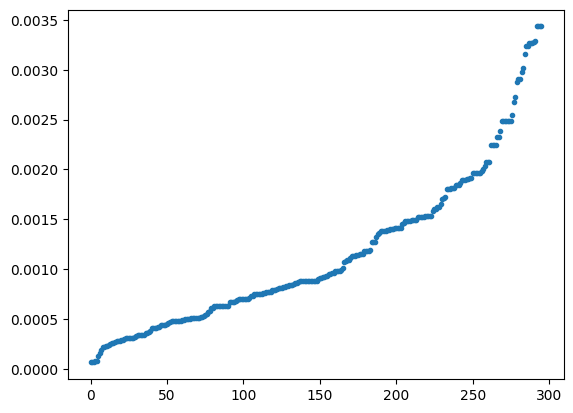

In [12]:
plt.plot(np.sort(cm.matched["2d_sep"]), '.')

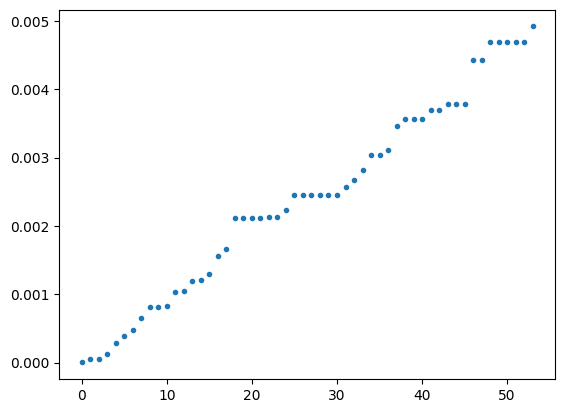

In [13]:
plt.plot(np.sort(cm.matched["3d_sep"]), '.')

In [14]:
Counter(cm.catalogue["pl_name"])

Counter({np.str_('Kepler-1167 b'): 1,
         np.str_('Kepler-1740 b'): 1,
         np.str_('Kepler-1581 b'): 1,
         np.str_('Kepler-644 b'): 1,
         np.str_('Kepler-1752 b'): 1,
         np.str_('Kepler-280 c'): 1,
         np.str_('Kepler-1208 b'): 1,
         np.str_('Kepler-263 c'): 1,
         np.str_('Kepler-1101 b'): 1,
         np.str_('HD 168746 b'): 1,
         np.str_('K2-19 b'): 1,
         np.str_('Kepler-560 b'): 1,
         np.str_('Kepler-150 d'): 1,
         np.str_('Kepler-498 b'): 1,
         np.str_('Kepler-817 b'): 1,
         np.str_('Kepler-937 b'): 1,
         np.str_('K2-10 b'): 1,
         np.str_('Kepler-571 b'): 1,
         np.str_('Kepler-1458 b'): 1,
         np.str_('K2-335 b'): 1,
         np.str_('Kepler-1600 c'): 1,
         np.str_('Kepler-221 d'): 1,
         np.str_('Kepler-626 b'): 1,
         np.str_('Kepler-1549 b'): 1,
         np.str_('K2-62 c'): 1,
         np.str_('Kepler-1149 b'): 1,
         np.str_('Kepler-1288 b'): 1,
         n

In [15]:
final = cm.combined_crossmatch(input)
print(len(cm.id_matched))
print(len(cm.coords3d_matched))
print(len(cm.coords2d_matched))
print(Counter(final["match_type"]))
print(len(final), len(set(final["pl_name"]))) # this shouldn't happen
# final["pl_name", "match_type"]].to_pandas().sort_values("pl_name").to_csv("final_crossmatch.csv", index=False)
# final["pl_name", "match_type"].to_pandas().groupby("pl_name").count().sort_values("match_type", ascending=False)
final["pl_name", "star_name", "hostname", "id", "match_type"][np.isin(final["pl_name"], ["HD 46375 b", "DS Tuc A b",  "GJ 887 b", "GJ 887 c", "GJ 887 d"])]
# we conclude that the combination might work, but both methods can produce duplicates, need to further investigate why

477
152
727
Counter({np.str_('id'): 477, np.str_('2d'): 296, np.str_('3d'): 54})
827 823


pl_name,star_name,hostname,id,match_type
str29,str29,str27,str23,str2
GJ 887 b,TIC 471015557,GJ 887,GJ 887,id
GJ 887 b,TIC 155315739,GJ 887,GJ 887,id
GJ 887 c,TIC 471015557,GJ 887,GJ 887,id
GJ 887 c,TIC 155315739,GJ 887,GJ 887,id
GJ 887 d,TIC 471015557,GJ 887,GJ 887,id
GJ 887 d,TIC 155315739,GJ 887,GJ 887,id
HD 46375 b,TIC 234928947,HD 46375,--,2d
DS Tuc A b,TIC 410214986,DS Tuc A,--,2d


In [16]:
Counter(cm.alternate_ids["id"].data.data)

Counter({np.str_('0'): 815,
         np.str_('1RXS J230547.3-355125'): 2,
         np.str_('TYC 7512-1263-1'): 2,
         np.str_('TIC 471015557'): 2,
         np.str_('TIC 155315739'): 2,
         np.str_('GJ 887'): 2,
         np.str_('Gaia DR3 6553614253923452800'): 2,
         np.str_('GC 32159'): 2,
         np.str_('UGP 591'): 2,
         np.str_('2MASS J23055131-3551130'): 2,
         np.str_('PLX 5584'): 2,
         np.str_('CNS5 5688'): 2,
         np.str_('AC2000 3355101'): 2,
         np.str_('CD-36 15693'): 2,
         np.str_('CPC 18 11792'): 2,
         np.str_('CPD-36  9694'): 2,
         np.str_('CSV   8819'): 2,
         np.str_('Ci 20 1400'): 2,
         np.str_('GCRV 14482'): 2,
         np.str_('GEN# +1.00217987'): 2,
         np.str_('HD 217987'): 2,
         np.str_('HIC 114046'): 2,
         np.str_('HIP 114046'): 2,
         np.str_('IRAS 23029-3607'): 2,
         np.str_('JP11  3579'): 2,
         np.str_('LFT 1758'): 2,
         np.str_('LHS    70'): 2,
     

In [17]:
cm.alternate_ids[cm.alternate_ids["id"].data.data == "0"]

input_ids,id
str29,str33
TIC 522415725,--
TIC 67906570,--
TIC 514768737,--
TIC 1961255595,--
TIC 471013491,--
TIC 97600027,--
TIC 506939512,--
TIC 1203373581,--
TIC 518659900,--


In [18]:
# look at "invalid" entries
alt_ids = cm.alternate_ids["id"]
cm.alternate_ids[alt_ids.mask]

input_ids,id
str29,str33
TIC 522415725,--
TIC 67906570,--
TIC 514768737,--
TIC 1961255595,--
TIC 471013491,--
TIC 97600027,--
TIC 506939512,--
TIC 1203373581,--
TIC 518659900,--


In [ ]:
input_plus_1alt = input.copy()
input_plus_1alt.add_row({"star_name": "GJ 702 A"})
input_plus_1alt[-1]
# cm.load_alternate_ids(input_plus_1alt["star_name"])

input_ids,id
str29,str33
TIC 459832522,TIC 459832522
TIC 459832522,AP J14153968+1910558
TIC 459832522,GALAH 150210005801171
TIC 459832522,GJ 541
TIC 459832522,HIP 69673
TIC 459832522,PLX 3242
TIC 459832522,LSPM J1415+1910
TIC 459832522,NLTT 36756
TIC 459832522,TYC 1472-1436-1


In [41]:
cm.alternate_ids.write("alternate_ids_1dupe.txt", format="ascii")

In [42]:
cm.load_alternate_ids(input_plus_1alt["star_name"], from_file="alternate_ids_1dupe.txt")

input_ids,id
str29,str33
TIC 459832522,TIC 459832522
TIC 459832522,AP J14153968+1910558
TIC 459832522,GALAH 150210005801171
TIC 459832522,GJ 541
TIC 459832522,HIP 69673
TIC 459832522,PLX 3242
TIC 459832522,LSPM J1415+1910
TIC 459832522,NLTT 36756
TIC 459832522,TYC 1472-1436-1


In [ ]:
dupes = cm.find_duplicates(input_plus_1alt)
dupes.pprint_all()

         input_ids                            duplicate_names                  appearances
---------------------------- ------------------------------------------------- -----------
                  * 70 Oph A      ['* 70 Oph A', 'GJ 702 A', 'TIC 1674663309']           3
GAIA DR3 3111066471465385216 ['GAIA DR3 3111066471465385216', 'TIC 262722576']           2
               TIC 143203922                ['TIC 143203922', 'TIC 471012437']           2
               TIC 155315739                ['TIC 155315739', 'TIC 471015557']           2
               TIC 436933290                ['TIC 436933290', 'TIC 436933294']           2
               TIC 437127546                ['TIC 437127546', 'TIC 471012765']           2
               TIC 471012273                 ['TIC 471012273', 'TIC 98755656']           2


In [ ]:
cm.alternate_ids

input_ids,id
str29,str33
TIC 459832522,TIC 459832522
TIC 459832522,AP J14153968+1910558
TIC 459832522,GALAH 150210005801171
TIC 459832522,GJ 541
TIC 459832522,HIP 69673
TIC 459832522,PLX 3242
TIC 459832522,LSPM J1415+1910
TIC 459832522,NLTT 36756
TIC 459832522,TYC 1472-1436-1


In [ ]:
joined = df.merge(
    df['input_ids'], 
    left_on='id', 
    right_on='input_ids', 
    suffixes=('', '_linked')
)
result = joined.groupby('input_ids')['input_ids_linked'].unique().reset_index()
result['duplicate_names'] = result.apply(
    lambda x: sorted(list(set(x['input_ids_linked']) | {x['input_ids']})), 
    axis=1
)
result['appearances'] = result['duplicate_names'].apply(len)
result.drop(columns=['input_ids_linked'], inplace=True)
result = result[result['appearances'] > 1]
return Table.from_pandas(result)

NameError: name 'df' is not defined

In [ ]:
cm.remove_duplicates(input)
# fucked soething up, it's linking stars that shouldn't be linked by simbad

  star_name   sy_dist st_spectype       st_rad       st_teff      st_mass       st_age        ra              dec        sy_vmag sy_jmag sy_hmag sy_kmag known_binary_fl gaia_binary_fl WDSsep    wds_deltamag   
------------- ------- ----------- ------------------ ------- ------------------ ------ ---------------- ---------------- ------- ------- ------- ------- --------------- -------------- ------ ------------------
   * 70 Oph A    5.11         K0V  0.881947100162506  5270.0  0.825645804405212   null 271.363535054996 2.50014628193139    null    null    null    null            True           null   null               null
TIC 368326352    13.0      G3III: 14.205526091276626  5205.0 0.8851835852264439   null        79.172437        45.997898    null    null    null    null               1              0    0.0 0.0999999999999999
[np.int64(8), np.int64(6)]
0
[np.int64(0)]
  star_name   sy_dist st_spectype       st_rad       st_teff      st_mass       st_age     ra       dec    sy_vmag sy

star_name,sy_dist,st_spectype,st_rad,st_teff,st_mass,st_age,ra,dec,sy_vmag,sy_jmag,sy_hmag,sy_kmag,known_binary_fl,gaia_binary_fl,WDSsep,wds_deltamag
str29,float64,str18,float64,str18,float64,str18,float64,float64,str18,str18,str18,str18,str5,str4,str18,str19
TIC 471011144,1.3474909718104888,K1V,0.899855262848747,5244.0,0.8959186306211407,null,219.903981,-60.837157,null,null,null,null,1,0,5.3,-1.34
TIC 280310048,3.497359493582345,F5IV-V+DQZ,2.0633565402794045,658y4.0,1.53,1.74,114.825217,5.224936,null,null,null,null,1,0,3.8,10.34
TIC 471011145,1.3474909718104888,G2V,1.2862532752257885,5776.0,1.035213484399243,null,219.910043,-60.833976,null,null,null,null,1,0,5.3,1.34
TIC 157587146,7.756146746296439,A0Va,2.8423168672992976,9458.3,2.4052352692799066,null,279.234764,38.783747,null,null,null,null,1,0,84.5,9.41
TIC 423088367,10.358400662937642,K0IIIb,8.840276440775776,4860.0,2.02,1.2882495516931325,116.328966,28.026137,null,null,null,null,1,0,39.8,12.37
TIC 440388263,24.86943546381497,A1IV-Vp,4.449358685806391,8848.7,2.2264341531921854,null,89.88216396171,44.94743634981,1.71414,1.71414,1.71414,1.71414,1,0,0.0,0.2000000000000001
TIC 70257116,5.12952038984355,A7Vn,1.7915292251488666,7747.2,1.8281924586383476,null,297.695844,8.868386,null,null,null,null,1,0,195.8,8.870000000000001
TIC 99843265,37.67897513187641,G9III+A7.5,29.56022172925343,4627.0,0.7339396124372838,null,165.931834,61.750945,null,null,null,null,1,0,0.8,2.93
TIC 229540730,38.774718883288095,K4-III,41.79640191860209,4043.0,0.6322828325926475,null,222.676488,74.15555,null,null,null,null,1,0,212.3,10.55


In [ ]:
list(input[25])

[np.str_('TIC 290374453'),
 np.float64(34.698126301179734),
 np.str_('A1III-'),
 np.float64(6.671189239049228),
 np.str_('8910.0'),
 np.float64(2.2451884408598257),
 np.str_('null'),
 np.float64(138.299889),
 np.float64(-69.717166),
 np.str_('null'),
 np.str_('null'),
 np.str_('null'),
 np.str_('null'),
 np.str_('0'),
 np.str_('0'),
 np.str_('null'),
 np.str_('null')]

In [ ]:
np.isin(list(input[25]), [None, np.nan, "null", 0, '0']).sum()

np.int64(9)